In [ ]:
# Optional package installation
# def pip_install(pkgs):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# pip_install([
#     "cdsapi",
#     "copernicusmarine",
#     "xarray",
#     "netCDF4",
#     "h5netcdf",
#     "pandas",
#     "numpy",
#     "matplotlib",
#     "seaborn",
#     "scikit-learn",
#     "python-dateutil",
#     "tqdm"
# ])

# print("✅ Installed required packages")

df_era5_d: (13201, 8)
df_wave_d: (13272, 3)
era5 idx: 1990-01-01 00:00:00 -> 2026-02-21 00:00:00 <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
wave idx: 1990-01-01 00:00:00 -> 2026-05-03 00:00:00 <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Intersection length: 13201
Intersection sample: DatetimeIndex(['1990-01-01', '1990-01-02', '1990-01-03', '1990-01-04',
               '1990-01-05'],
              dtype='datetime64[ns]', freq='D')


In [ ]:
# Parameters
DATA_CACHE_PATH = "data_cache"
FORECAST_DATE = "2025-01-13"  # <- validation date: compare vs SWnew_01132025.kml
CDS_API_KEY = None
CMEMS_USER = None
CMEMS_PASS = None
# Use cached data to avoid network downloads during validation.
RUN_MODE = "quick"


In [2]:
import os

# RUN_MODE is injected by papermill into the parameters cell above
QUICK_MODE = (RUN_MODE == "quick")

if QUICK_MODE:
    print("⚡ QUICK MODE — skipping data download and model training")
    print("   Using cached datasets and pre-trained model from data_cache/")
else:
    print("⟳ FULL MODE — downloading fresh data and retraining model")

⟳ FULL MODE — downloading fresh data and retraining model


In [3]:
import os, datetime as dt
from dateutil.relativedelta import relativedelta

# --------------------------
# Credentials from ENV vars
# --------------------------
CDS_URL = "https://cds.climate.copernicus.eu/api"
CDS_KEY = CDS_API_KEY or os.getenv("CDS_API_KEY")
CMEMS_USER = CMEMS_USER or os.getenv("CMEMS_USER")
CMEMS_PASS = CMEMS_PASS or os.getenv("CMEMS_PASS")

# Only require credentials in full mode (quick mode uses cached data)
if not QUICK_MODE:
    assert CDS_KEY, "Set CDS_API_KEY env variable (restart terminal after setx)"
    assert CMEMS_USER and CMEMS_PASS, "Set CMEMS_USER and CMEMS_PASS env variables"
    print("Credentials: CDS_API_KEY and CMEMS credentials loaded")
else:
    print("Quick mode: skipping credential checks (using cached data)")

# --------------------------
# Beach bounding box (Waskaduwa)
# --------------------------
LAT_MIN, LAT_MAX = 6.611656, 6.638294
LON_MIN, LON_MAX = 79.936194, 79.947092

# --------------------------
# Optional fixed training cutoff for validation
# --------------------------
TRAIN_CUTOFF_DATE = dt.date(2024, 4, 2)

# --------------------------
# Training window (daily)
# --------------------------
TODAY = dt.date.today()

# Default behaviour: end at TODAY - 7 days (ERA5 latency buffer)
DEFAULT_END = TODAY - dt.timedelta(days=7)

if TRAIN_CUTOFF_DATE:
    END_DATE = TRAIN_CUTOFF_DATE
else:
    END_DATE = DEFAULT_END

START_DATE = END_DATE - relativedelta(years=3)

# --------------------------
# Target forecast date (for validation: 2025-01-13)
# --------------------------
FORECAST_DATE_INPUT = "2025-01-13"
if FORECAST_DATE_INPUT is None or str(FORECAST_DATE_INPUT).strip() == "":
    TARGET_DATE = TODAY + dt.timedelta(days=30)
else:
    TARGET_DATE = dt.datetime.strptime(str(FORECAST_DATE_INPUT), "%Y-%m-%d").date()

FORECAST_DAYS = (TARGET_DATE - TODAY).days
print(f"✅ Target date: {TARGET_DATE}")
print(f"✅ Days from today: {FORECAST_DAYS}")

print("\n" + "="*70)
print("VALIDATION RUN CONFIG")
print("="*70)
print(f"Bounding box (Waskaduwa): LAT [{LAT_MIN}, {LAT_MAX}] LON [{LON_MIN}, {LON_MAX}]")
print(f"Training window:          {START_DATE} -> {END_DATE}")
print(f"Forecast target date:     {TARGET_DATE} (validation vs SWnew_01132025.kml)")
print(f"Days offset:              {FORECAST_DAYS}")
print("="*70 + "\n")

Credentials: CDS_API_KEY and CMEMS credentials loaded
✅ Target date: 2025-01-13
✅ Days from today: -476

VALIDATION RUN CONFIG
Bounding box (Waskaduwa): LAT [6.611656, 6.638294] LON [79.936194, 79.947092]
Training window:          2021-04-02 -> 2024-04-02
Forecast target date:     2025-01-13 (validation vs SWnew_01132025.kml)
Days offset:              -476



In [4]:
from pathlib import Path

DATA_DIR  = Path("data_cache")
CMEMS_DIR = DATA_DIR / "cmems"
DATA_DIR.mkdir(exist_ok=True, parents=True)
CMEMS_DIR.mkdir(exist_ok=True, parents=True)

# ERA5: you already downloaded history manually using CDS API code
ERA5_HISTORY_FILE = DATA_DIR / "era5_history_1990_2025.csv"   # put your file here
ERA5_UPDATE_FILE  = DATA_DIR / "era5_update_2026_to_now.csv"
ERA5_FULL_FILE    = DATA_DIR / "era5_full_merged.csv"

print("✅ Cache folder:", DATA_DIR.resolve())
print("✅ Expect ERA5 history file at:", ERA5_HISTORY_FILE.resolve())


# ✅ CHANGE this to your exact downloaded reanalysis nc filename
CMEMS_REAN_FILE = CMEMS_DIR / "cmems_wave_reanalysis_1990_2025.nc"
assert CMEMS_REAN_FILE.exists(), f"❌ Reanalysis file not found: {CMEMS_REAN_FILE}"
print("✅ Reanalysis file:", CMEMS_REAN_FILE)

✅ Cache folder: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\short-term component\data_cache
✅ Expect ERA5 history file at: C:\Users\Tharu\OneDrive\Documents\GitHub\coastalai\short-term component\data_cache\era5_history_1990_2025.csv
✅ Reanalysis file: data_cache\cmems\cmems_wave_reanalysis_1990_2025.nc


In [5]:
# ERA5 time-series requires ONE point (nearest 0.25° grid)
ERA5_LON = round(((LON_MIN + LON_MAX) / 2) / 0.25) * 0.25
ERA5_LAT = round(((LAT_MIN + LAT_MAX) / 2) / 0.25) * 0.25

print("✅ ERA5 point (0.25° grid):", {"lon": ERA5_LON, "lat": ERA5_LAT})

✅ ERA5 point (0.25° grid): {'lon': 80.0, 'lat': 6.5}


In [6]:
import cdsapi
import pandas as pd

import zipfile
import os

from pathlib import Path

def download_era5_update_csv(start_date: dt.date, end_date: dt.date, out_csv: Path):
    """
    Downloads ERA5 update. Handles ZIP response correctly and renames extracted file safely.
    Produces exactly: out_csv (a CSV file).
    """
    dataset = "reanalysis-era5-single-levels-timeseries"
    request = {
        "variable": [
            "10m_wind_gust_since_previous_post_processing",
            "mean_sea_level_pressure",
            "sea_surface_temperature",
            "total_precipitation",
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
        ],
        "location": {"longitude": float(ERA5_LON), "latitude": float(ERA5_LAT)},
        "date": [f"{start_date}/{end_date}"],
        "data_format": "csv"
    }

    out_csv.parent.mkdir(parents=True, exist_ok=True)

    if out_csv.exists():
        print("✅ Using cached ERA5 update:", out_csv)
        return

    tmp_file = out_csv.with_suffix(".download")

    # list files before download (so we detect what got extracted)
    before = set(out_csv.parent.glob("*"))

    client = cdsapi.Client(url=CDS_URL, key=CDS_KEY)
    print("⬇ Downloading ERA5 update...")
    client.retrieve(dataset, request).download(str(tmp_file))

    # check if zip
    with open(tmp_file, "rb") as f:
        sig = f.read(4)

    if sig == b"PK\x03\x04":
        print("📦 ZIP detected. Extracting...")

        with zipfile.ZipFile(tmp_file, "r") as z:
            z.extractall(out_csv.parent)

        os.remove(tmp_file)

        after = set(out_csv.parent.glob("*"))
        new_files = [p for p in (after - before) if p.suffix.lower() == ".csv"]

        if not new_files:
            raise RuntimeError("❌ ZIP extracted but no new CSV found.")

        # if multiple, pick the largest (usually the data file)
        new_files.sort(key=lambda p: p.stat().st_size, reverse=True)
        extracted_csv = new_files[0]

        extracted_csv.replace(out_csv)
        print("✅ Extracted CSV saved as:", out_csv)

    else:
        # it was already a csv download
        tmp_file.replace(out_csv)
        print("✅ CSV saved as:", out_csv)



def merge_era5_history_and_update(history_csv: Path, update_csv: Path, merged_csv: Path):
    assert history_csv.exists(), f"❌ Missing history file: {history_csv}"
    assert update_csv.exists(),  f"❌ Missing update file: {update_csv}"

    df_hist = pd.read_csv(history_csv)
    df_upd  = pd.read_csv(update_csv)


    if "date" not in df_hist.columns and "valid_time" in df_hist.columns:
        df_hist = df_hist.rename(columns={"valid_time": "date"})
    if "date" not in df_upd.columns and "valid_time" in df_upd.columns:
        df_upd = df_upd.rename(columns={"valid_time": "date"})

    if "date" not in df_hist.columns or "date" not in df_upd.columns:
        raise ValueError("❌ ERA5 CSV must include a 'date' column")

    df = pd.concat([df_hist, df_upd], ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    df = df.drop_duplicates(subset=["date"]).sort_values("date")
    df.to_csv(merged_csv, index=False)
    print("✅ ERA5 merged saved:", merged_csv)


# ---- Update range: 2026 onward ----
UPDATE_START = dt.date(2026, 1, 1)
UPDATE_END   = END_DATE

if not QUICK_MODE:
    download_era5_update_csv(UPDATE_START, UPDATE_END, ERA5_UPDATE_FILE)
    merge_era5_history_and_update(ERA5_HISTORY_FILE, ERA5_UPDATE_FILE, ERA5_FULL_FILE)
else:
    print("⚡ Skipping ERA5 download — using cached:", ERA5_FULL_FILE)
    assert ERA5_FULL_FILE.exists(), f"❌ Cached file missing: {ERA5_FULL_FILE}"

✅ Using cached ERA5 update: data_cache\era5_update_2026_to_now.csv
✅ ERA5 merged saved: data_cache\era5_full_merged.csv


In [7]:
import numpy as np

if ERA5_FULL_FILE.exists():
    df_era5 = pd.read_csv(ERA5_FULL_FILE)
else:
    # Fall back to history file if merged full file is not available
    print("⚠️ ERA5 full merged file not found — falling back to history file:", ERA5_HISTORY_FILE)
    df_era5 = pd.read_csv(ERA5_HISTORY_FILE)
df_era5["date"] = pd.to_datetime(df_era5["date"])
df_era5 = df_era5.set_index("date").sort_index()

df_era5_d = df_era5.resample("D").mean()
df_era5_d.columns = [c.lower() for c in df_era5_d.columns]

print("✅ ERA5 daily:", df_era5_d.shape)
df_era5_d.head()

✅ ERA5 daily: (13201, 8)


,u10,v10,fg10,msl,sst,tp,latitude,longitude
date,,,,,,,,
1990-01-01,0.101126,0.510350,3.809626,100993.638333,NaN,0.000014,6.5,80.0
1990-01-02,0.131521,-0.525434,3.994461,100976.078333,NaN,0.000016,6.5,80.0
1990-01-03,-0.330767,-0.624918,5.022973,101042.382708,NaN,0.000022,6.5,80.0
1990-01-04,-0.785084,-4.221357,6.293090,101111.963750,NaN,0.001573,6.5,80.0
1990-01-05,-1.353758,-4.339353,12.074156,100849.732083,NaN,0.004579,6.5,80.0


In [8]:
# How many NaNs in each important column
check_cols = [c for c in ["sst", "msl", "tp", "u10", "v10", "fg10"] if c in df_era5_d.columns]
print(df_era5_d[check_cols].isna().sum())

# % missing (easy to see if it's 100% empty)
print((df_era5_d[check_cols].isna().mean() * 100).round(2))

# Quick peek of SST values
if "sst" in df_era5_d.columns:
    print("SST non-null count:", df_era5_d["sst"].notna().sum())
    print(df_era5_d["sst"].head(10))

sst     13201
msl         0
tp          0
u10         0
v10         0
fg10        0
dtype: int64
sst     100.0
msl       0.0
tp        0.0
u10       0.0
v10       0.0
fg10      0.0
dtype: float64
SST non-null count: 0
date
1990-01-01   NaN
1990-01-02   NaN
1990-01-03   NaN
1990-01-04   NaN
1990-01-05   NaN
1990-01-06   NaN
1990-01-07   NaN
1990-01-08   NaN
1990-01-09   NaN
1990-01-10   NaN
Freq: D, Name: sst, dtype: float64


In [9]:
if "sst" in df_era5_d.columns:
    df_era5_d = df_era5_d.drop(columns=["sst"])
    print("✅ Dropped empty sst column from ERA5")

✅ Dropped empty sst column from ERA5


In [10]:
import datetime as dt
import copernicusmarine as cm

# Only login when running full mode (quick mode uses cached files)
if not QUICK_MODE:
    cm.login(username=CMEMS_USER, password=CMEMS_PASS, force_overwrite=True)

ANFC_DATASET_ID = "cmems_mod_glo_wav_anfc_0.083deg_PT3H-i"
ANFC_VARS = ["VHM0", "VMDR", "VTPK"]

# Start right after reanalysis end (next 3-hour step)
ANFC_START = dt.datetime(2025, 12, 1, 0, 0, 0)

# Real-time end (UTC) with buffer (avoid requesting not-yet-ready timesteps)
ANFC_END = dt.datetime.utcnow() - dt.timedelta(hours=6)

start_iso = ANFC_START.strftime("%Y-%m-%dT%H:%M:%S")
end_iso   = ANFC_END.strftime("%Y-%m-%dT%H:%M:%S")

CMEMS_ANFC_FILE = CMEMS_DIR / f"cmems_wave_anfc_{ANFC_START.date()}_{ANFC_END.date()}.nc"

if not QUICK_MODE:
    if CMEMS_ANFC_FILE.exists():
        print("✅ Using cached ANFC:", CMEMS_ANFC_FILE)
    else:
        cm.subset(
            dataset_id=ANFC_DATASET_ID,
            variables=ANFC_VARS,
            minimum_latitude=LAT_MIN,
            maximum_latitude=LAT_MAX,
            minimum_longitude=LON_MIN,
            maximum_longitude=LON_MAX,
            start_datetime=start_iso,
            end_datetime=end_iso,
            output_directory=str(CMEMS_DIR),
            output_filename=CMEMS_ANFC_FILE.name,
            force_download=True,
        )
        print("✅ ANFC saved:", CMEMS_ANFC_FILE)
else:
    # Find the most recent ANFC file in cache
    existing = sorted(CMEMS_DIR.glob("cmems_wave_anfc_*.nc"), reverse=True)
    assert existing, "❌ No cached ANFC file found. Run Full Rerun first."
    CMEMS_ANFC_FILE = existing[0]
    print("⚡ Skipping CMEMS download — using cached:", CMEMS_ANFC_FILE)

c:\Users\Tharu\anaconda3\envs\coastal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO - 2026-05-04T11:35:54Z - Credentials file stored in C:\Users\Tharu\.copernicusmarine\.copernicusmarine-credentials.


✅ Using cached ANFC: data_cache\cmems\cmems_wave_anfc_2025-12-01_2026-05-04.nc


In [11]:
import xarray as xr
import pandas as pd
from pathlib import Path

def wave_nc_to_daily_df(nc_path: Path) -> pd.DataFrame:
    ds = xr.open_dataset(nc_path)

    lat_name = "latitude" if "latitude" in ds.dims else "lat"
    lon_name = "longitude" if "longitude" in ds.dims else "lon"
    time_name = "time"

    # mean over your bbox grid cells
    ds_mean = ds.mean(dim=[lat_name, lon_name], skipna=True)

    df = ds_mean.to_dataframe().reset_index()
    df[time_name] = pd.to_datetime(df[time_name])
    df = df.set_index(time_name).sort_index()

    # daily average
    df_d = df.resample("D").mean()
    df_d.columns = [c.lower() for c in df_d.columns]

    return df_d

In [12]:
df_rean_d = wave_nc_to_daily_df(CMEMS_REAN_FILE)
df_anfc_d = wave_nc_to_daily_df(CMEMS_ANFC_FILE)

# Merge + dedupe on date index
df_wave_d = pd.concat([df_rean_d, df_anfc_d], axis=0)
df_wave_d = df_wave_d[~df_wave_d.index.duplicated(keep="last")].sort_index()

print("✅ Waves daily merged:", df_wave_d.shape)
df_wave_d.head()

✅ Waves daily merged: (13273, 3)


,vhm0,vmdr,vtpk
time,,,
1990-01-01,0.61000,206.101257,10.13250
1990-01-02,0.66375,217.940002,14.13625
1990-01-03,0.72000,239.412506,16.62125
1990-01-04,0.77625,265.200012,15.57000
1990-01-05,1.12000,320.382507,11.00500


In [13]:
import numpy as np

# Join (outer) then interpolate small gaps
df = df_era5_d.join(df_wave_d, how="outer")
df = df.interpolate(method="time").dropna()
df.columns = [c.lower() for c in df.columns]

# Wind speed from u/v
u_candidates = ["u10", "10m_u_component_of_wind"]
v_candidates = ["v10", "10m_v_component_of_wind"]

u_col = next((c for c in u_candidates if c in df.columns), None)
v_col = next((c for c in v_candidates if c in df.columns), None)

if u_col and v_col:
    df["wind_speed"] = np.sqrt(df[u_col]**2 + df[v_col]**2)

# Wave energy proxy
if "vhm0" in df.columns:
    df["wave_energy"] = df["vhm0"]**2

# Cyclic time features
idx = df.index
df["doy_sin"]   = np.sin(2*np.pi*idx.day_of_year/365.0)
df["doy_cos"]   = np.cos(2*np.pi*idx.day_of_year/365.0)
df["month_sin"] = np.sin(2*np.pi*idx.month/12.0)
df["month_cos"] = np.cos(2*np.pi*idx.month/12.0)

print("✅ final merged df:", df.shape)
df.head()

✅ final merged df: (13273, 16)


,u10,v10,fg10,msl,tp,latitude,longitude,vhm0,vmdr,vtpk,wind_speed,wave_energy,doy_sin,doy_cos,month_sin,month_cos
1990-01-01,0.101126,0.510350,3.809626,100993.638333,0.000014,6.5,80.0,0.61000,206.101257,10.13250,0.520272,0.372100,0.017213,0.999852,0.5,0.866025
1990-01-02,0.131521,-0.525434,3.994461,100976.078333,0.000016,6.5,80.0,0.66375,217.940002,14.13625,0.541644,0.440564,0.034422,0.999407,0.5,0.866025
1990-01-03,-0.330767,-0.624918,5.022973,101042.382708,0.000022,6.5,80.0,0.72000,239.412506,16.62125,0.707057,0.518400,0.051620,0.998667,0.5,0.866025
1990-01-04,-0.785084,-4.221357,6.293090,101111.963750,0.001573,6.5,80.0,0.77625,265.200012,15.57000,4.293741,0.602564,0.068802,0.997630,0.5,0.866025
1990-01-05,-1.353758,-4.339353,12.074156,100849.732083,0.004579,6.5,80.0,1.12000,320.382507,11.00500,4.545618,1.254400,0.085965,0.996298,0.5,0.866025


In [14]:
candidate_targets = [
    "wind_speed",
    "fg10",      # gust
    "msl",       # mean sea level pressure
    "tp",        # total precipitation
    "vhm0", "vtpk", "vmdr",
    "wave_energy"
]

TARGET_COLS = [c for c in candidate_targets if c in df.columns]
TIME_COLS = ["doy_sin", "doy_cos", "month_sin", "month_cos"]
FEATURE_COLS = TARGET_COLS + TIME_COLS

print("✅ TARGET_COLS :", TARGET_COLS)
print("✅ FEATURE_COLS:", FEATURE_COLS)

✅ TARGET_COLS : ['wind_speed', 'fg10', 'msl', 'tp', 'vhm0', 'vtpk', 'vmdr', 'wave_energy']
✅ FEATURE_COLS: ['wind_speed', 'fg10', 'msl', 'tp', 'vhm0', 'vtpk', 'vmdr', 'wave_energy', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']


Save the final Dataset

In [15]:
df.index.name = "date"

OUT_FILE = DATA_DIR / "final_era5_cmems_daily_features.csv"
df.to_csv(OUT_FILE, index=True)
print("✅ Saved:", OUT_FILE)

✅ Saved: data_cache\final_era5_cmems_daily_features.csv


In [16]:
import pandas as pd
import numpy as np

def dataset_health_report(df, name="dataset"):
    print("\n" + "="*70)
    print(f"📦 DATASET HEALTH REPORT: {name}")
    print("="*70)
    print("Rows:", len(df))
    print("Date range:", df.index.min().date(), "→", df.index.max().date())
    print("Duplicate dates:", int(df.index.duplicated().sum()))

    # Missing %
    miss = df.isna().mean().sort_values(ascending=False) * 100
    top_miss = miss[miss > 0].head(15)

    if len(top_miss) == 0:
        print("✅ No missing values.")
    else:
        print("⚠️ Missing values (%), top columns:")
        print(top_miss.round(2).to_string())

    # Infinite values
    inf_cols = np.isinf(df.select_dtypes(include=[np.number])).sum()
    inf_cols = inf_cols[inf_cols > 0]
    if len(inf_cols) > 0:
        print("⚠️ Infinite values found:")
        print(inf_cols.to_string())
    else:
        print("✅ No infinite values.")

def load_env_csv(env_csv_path):
    df = pd.read_csv(env_csv_path)
    if "date" not in df.columns:
        raise ValueError("ENV CSV must include 'date' column")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).set_index("date").sort_index()

    # Convert numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop duplicate dates
    df = df[~df.index.duplicated(keep="last")]

    # Replace inf with nan
    df = df.replace([np.inf, -np.inf], np.nan)

    dataset_health_report(df, name="final_era5_cmems_daily_features")

    print("\n✅ Latest available ENV date:", df.index.max().date())
    return df

hist = load_env_csv(DATA_DIR / "final_era5_cmems_daily_features.csv")


📦 DATASET HEALTH REPORT: final_era5_cmems_daily_features
Rows: 13273
Date range: 1990-01-01 → 2026-05-04
Duplicate dates: 0
✅ No missing values.
✅ No infinite values.

✅ Latest available ENV date: 2026-05-04


Preparing dataset done!

In [17]:
import os, glob, re
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path

DATA_DIR   = Path("data_cache")
KML_FOLDER = DATA_DIR / "shorelines_kml"
ENV_CSV    = DATA_DIR / "final_era5_cmems_daily_features.csv"
OUTPUT_DIR = DATA_DIR / "output_forecasts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METERS_PER_DEGREE = 111_000.0

# ── KML reader ──
def parse_kml_shorelines(kml_folder):
    shorelines = []
    files = sorted(glob.glob(str(kml_folder / "*.kml")))
    print(f"✅ Found {len(files)} KML files")
    for f in files:
        fname = os.path.basename(f)
        try:
            date_str = fname.replace("SWnew", "").replace(".kml", "").strip()
            if len(date_str) in (7, 8):
                dt_obj = datetime.strptime(date_str, "%m%d%Y")
            else:
                continue
            tree = ET.parse(f); root = tree.getroot()
            coords = []
            for elem in root.iter():
                if elem.tag.endswith("coordinates") and elem.text:
                    for p in elem.text.strip().split():
                        lon, lat, *_ = p.split(",")
                        coords.append([float(lon), float(lat)])
            if coords:
                shorelines.append({"date": dt_obj, "coords": np.array(coords), "file": fname})
        except Exception as e:
            print(f"⚠️ Skipping {fname}: {e}")
    shorelines.sort(key=lambda x: x["date"])
    return shorelines

def get_baseline(shorelines):
    pts = np.vstack([s["coords"] for s in shorelines])
    mean = pts.mean(axis=0); centered = pts - mean
    _, _, vt = np.linalg.svd(centered)
    direction = vt[0]; normal = np.array([-direction[1], direction[0]])
    return mean, direction, normal

def compute_transects(shorelines, n=100):
    if not shorelines: return pd.DataFrame(), None, None
    mean, direction, normal = get_baseline(shorelines)
    all_pts = np.vstack([s["coords"] for s in shorelines])
    proj = np.dot(all_pts - mean, direction)
    dist = np.linspace(proj.min(), proj.max(), n)
    origins = mean + np.outer(dist, direction)
    rows = []
    for s in shorelines:
        coords = s["coords"]
        x = np.dot(coords - mean, direction)
        y = np.dot(coords - mean, normal)
        order = np.argsort(x); x, y = x[order], y[order]
        _, idx = np.unique(x, return_index=True)
        y_interp = np.interp(dist, x[idx], y[idx])
        row = {"date": s["date"]}
        for i, v in enumerate(y_interp):
            row[f"t{i}"] = v
        rows.append(row)
    df_out = pd.DataFrame(rows).set_index("date")
    df_out.index = pd.to_datetime(df_out.index)
    return df_out, origins, normal

shorelines = parse_kml_shorelines(KML_FOLDER)
shore_df, transect_origins, normal_vec = compute_transects(shorelines, n=100)
if shore_df.empty:
    raise RuntimeError("❌ No transects. Check KML files.")
transect_cols = list(shore_df.columns)
print("✅ Original shore_df:", shore_df.shape)
shore_df.head()


✅ Found 19 KML files
✅ Original shore_df: (19, 100)


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t90,t91,t92,t93,t94,t95,t96,t97,t98,t99
date,,,,,,,,,,,,,,,,,,,,,
2012-05-01,0.000289,0.000367,0.000364,0.000366,0.000368,0.000361,0.000347,0.000345,0.000341,0.000294,...,0.000217,0.000235,0.000246,0.000252,0.000259,0.000265,0.000271,0.000276,0.000281,0.000567
2013-01-09,0.000302,0.000382,0.000382,0.000375,0.000355,0.000326,0.000299,0.000272,0.000247,0.000211,...,0.000189,0.000210,0.000248,0.000266,0.000258,0.000272,0.000270,0.000269,0.000274,0.000559
2013-11-01,0.000309,0.000311,0.000284,0.000265,0.000247,0.000227,0.000208,0.000180,0.000149,0.000119,...,0.000276,0.000302,0.000316,0.000323,0.000318,0.000313,0.000302,0.000293,0.000288,0.000559
2014-02-21,0.000284,0.000280,0.000271,0.000258,0.000244,0.000225,0.000210,0.000197,0.000174,0.000136,...,0.000264,0.000262,0.000270,0.000278,0.000286,0.000304,0.000318,0.000318,0.000318,0.000318
2014-08-15,0.000301,0.000341,0.000328,0.000304,0.000290,0.000283,0.000266,0.000244,0.000223,0.000188,...,0.000228,0.000251,0.000280,0.000316,0.000343,0.000348,0.000352,0.000357,0.000374,0.000543


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA AUGMENTATION
# Linearly interpolate shoreline positions between each consecutive pair of
# observed KML dates at a monthly (~30-day) cadence.
# This is physically sensible — shoreline change is gradual.
# ─────────────────────────────────────────────────────────────────────────────

aug_rows = []
sorted_idx = shore_df.sort_index().index
for i in range(len(sorted_idx) - 1):
    d0, d1 = sorted_idx[i], sorted_idx[i+1]
    v0, v1 = shore_df.loc[d0].values, shore_df.loc[d1].values
    days_gap = (d1 - d0).days
    # insert monthly intermediate points (skip if gap < 20 days)
    if days_gap < 20:
        continue
    n_steps = max(1, days_gap // 30)
    for k in range(1, n_steps):
        frac = k / n_steps
        new_date = d0 + pd.Timedelta(days=int(days_gap * frac))
        new_vals = v0 + frac * (v1 - v0)   # linear interpolation
        row = {"date": new_date}
        for j, col in enumerate(transect_cols):
            row[col] = new_vals[j]
        aug_rows.append(row)

df_aug = pd.DataFrame(aug_rows).set_index("date")
df_aug.index = pd.to_datetime(df_aug.index)

shore_df_aug = pd.concat([shore_df, df_aug]).sort_index()
shore_df_aug = shore_df_aug[~shore_df_aug.index.duplicated(keep="first")]

print(f"✅ Augmented shore_df: {len(shore_df)} → {len(shore_df_aug)} rows")
print(f"   Date range: {shore_df_aug.index.min().date()} → {shore_df_aug.index.max().date()}")


✅ Augmented shore_df: 19 → 147 rows
   Date range: 2012-05-01 → 2025-01-13


📋 ENVIRONMENTAL FEATURE SUMMARY
              u10         v10        fg10          msl          tp  \
count  13273.0000  13273.0000  13273.0000   13273.0000  13273.0000   
mean       1.9294      0.2206      5.9590  101005.5853      0.0003   
std        1.9466      1.4441      2.2301     148.3122      0.0004   
min       -4.0829     -8.6882      2.1823  100321.8621      0.0000   
25%        0.2270     -0.4696      4.0965  100905.5181      0.0001   
50%        1.5457      0.3028      5.3404  101004.6952      0.0002   
75%        3.5986      1.1158      7.4612  101105.5831      0.0005   
max        8.8795      6.7116     17.0791  101533.0810      0.0075   

             vhm0        vmdr        vtpk  wind_speed  wave_energy  \
count  13273.0000  13273.0000  13273.0000  13273.0000   13273.0000   
mean       1.1650    219.8976     12.5503      2.6218       1.6107   
std        0.5034     24.6179      3.2019      1.6648       1.3462   
min        0.3363    162.2525      5.0163      0.0194    

C:\Users\Tharu\AppData\Local\Temp\ipykernel_9948\4229868241.py:41: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Tharu\AppData\Local\Temp\ipykernel_9948\4229868241.py:42: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.savefig(str(OUTPUT_DIR / "correlation_heatmap.png"), dpi=120)
c:\Users\Tharu\anaconda3\envs\coastal\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


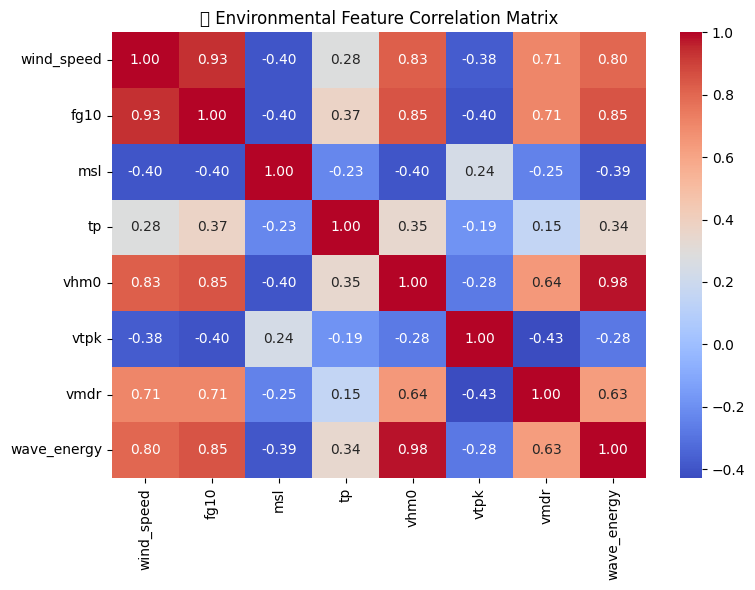

✅ Correlation heatmap saved


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load env features ──
def load_env_features(env_csv):
    df = pd.read_csv(env_csv)
    if "date" not in df.columns:
        raise ValueError("ENV CSV must include a 'date' column")
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.interpolate(method="time").ffill().bfill()
    return df

env_df = load_env_features(ENV_CSV)
env_cols_keep = [c for c in env_df.columns if c not in ["latitude","longitude"]]
env_df = env_df[env_cols_keep]

print("=" * 55)
print("📋 ENVIRONMENTAL FEATURE SUMMARY")
print("=" * 55)
print(env_df.describe().round(4))
print("\n📌 Missing values:")
print(env_df.isna().sum())

# ── Outlier clipping (IQR × 3) — gentle, preserves storm events ──
for col in env_df.select_dtypes(include=[np.number]).columns:
    q1, q3 = env_df[col].quantile(0.25), env_df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 3*iqr, q3 + 3*iqr
    env_df[col] = env_df[col].clip(lower, upper)

print("\n✅ Outlier clipping applied (IQR × 3)")

# ── Correlation heatmap ──
corr_cols = [c for c in ["wind_speed","fg10","msl","tp","vhm0","vtpk","vmdr","wave_energy"]
             if c in env_df.columns]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(env_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("🌊 Environmental Feature Correlation Matrix")
plt.tight_layout()
fig.savefig(str(OUTPUT_DIR / "correlation_heatmap.png"), dpi=120)
plt.show()
print("✅ Correlation heatmap saved")


In [33]:
# Add rolling features to env (30-day and 90-day means)
# =====================================================
# ✅ USE ENVIRONMENT VARIABLES ONLY (NO ROLLING)
# =====================================================

env_features = env_df.copy()

print("✅ Added cumulative + intensity + variability features")

# Merge: for each shoreline row, pick nearest preceding env row
merged_df = pd.merge_asof(
    shore_df_aug.sort_index(),
    env_features.sort_index(),   # ✅ IMPORTANT
    left_index=True, right_index=True,
    direction="backward",
)
# Env forward-fill (should already be complete)
env_fcols = [c for c in merged_df.columns if c not in transect_cols]
merged_df[env_fcols] = merged_df[env_fcols].ffill().bfill()
merged_df = merged_df.dropna(subset=transect_cols)

feature_cols = [c for c in merged_df.columns if c not in transect_cols]

# ─────────────────────────────
# ADD SHORELINE MEMORY FEATURES
# Previous observed/interpolated shoreline position is very important.
# ─────────────────────────────

shore_lag = shore_df_aug[transect_cols].shift(1)
shore_lag.columns = [f"{c}_lag1" for c in transect_cols]

merged_df = merged_df.join(shore_lag, how="left")
merged_df = merged_df.ffill().bfill()

feature_cols = [c for c in merged_df.columns if c not in transect_cols]

print("✅ Added shoreline lag features")
print("Total features:", len(feature_cols))



TRAIN_FILE = DATA_DIR / "final_training_dataset.csv"
merged_df.to_csv(TRAIN_FILE)


print("✅ Merged dataset:", merged_df.shape)
print("   Feature cols:", len(feature_cols))
print("   Training data saved:", TRAIN_FILE)
merged_df.head()


✅ Added cumulative + intensity + variability features
✅ Added shoreline lag features
Total features: 114
✅ Merged dataset: (147, 214)
   Feature cols: 114
   Training data saved: data_cache\final_training_dataset.csv


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t90_lag1,t91_lag1,t92_lag1,t93_lag1,t94_lag1,t95_lag1,t96_lag1,t97_lag1,t98_lag1,t99_lag1
date,,,,,,,,,,,,,,,,,,,,,
2012-05-01,0.000289,0.000367,0.000364,0.000366,0.000368,0.000361,0.000347,0.000345,0.000341,0.000294,...,0.000217,0.000235,0.000246,0.000252,0.000259,0.000265,0.000271,0.000276,0.000281,0.000567
2012-06-01,0.000290,0.000369,0.000366,0.000367,0.000367,0.000356,0.000341,0.000336,0.000329,0.000284,...,0.000217,0.000235,0.000246,0.000252,0.000259,0.000265,0.000271,0.000276,0.000281,0.000567
2012-07-03,0.000292,0.000371,0.000368,0.000368,0.000365,0.000352,0.000335,0.000327,0.000318,0.000273,...,0.000214,0.000232,0.000246,0.000254,0.000259,0.000266,0.000271,0.000275,0.000280,0.000566
2012-08-03,0.000294,0.000373,0.000371,0.000370,0.000363,0.000348,0.000329,0.000318,0.000306,0.000263,...,0.000210,0.000229,0.000246,0.000256,0.000259,0.000267,0.000271,0.000274,0.000279,0.000565
2012-09-04,0.000295,0.000374,0.000373,0.000371,0.000362,0.000344,0.000323,0.000309,0.000294,0.000253,...,0.000207,0.000226,0.000247,0.000257,0.000259,0.000268,0.000270,0.000273,0.000279,0.000564


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor

# ── Chronological 80/20 split — NO leakage ──
n = len(merged_df)
split = int(n * 0.80)

train_df = merged_df.iloc[:split]
test_df  = merged_df.iloc[split:]

X_train = train_df[feature_cols].values
y_train = train_df[transect_cols].values

X_test = test_df[feature_cols].values
y_test = test_df[transect_cols].values

# ── StandardScaler (fit on train only) ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("=" * 50)
print("📂 TRAIN / TEST SPLIT (chronological 80/20)")
print("=" * 50)
print(f"  Total rows  : {n}")
print(f"  Train rows  : {len(train_df)}  ({train_df.index.min().date()} → {train_df.index.max().date()})")
print(f"  Test rows   : {len(test_df)}   ({test_df.index.min().date()} → {test_df.index.max().date()})")
print(f"  Features    : {len(feature_cols)}")
print(f"  Transects   : {len(transect_cols)}")


📂 TRAIN / TEST SPLIT (chronological 80/20)
  Total rows  : 147
  Train rows  : 117  (2012-05-01 → 2022-07-08)
  Test rows   : 30   (2022-08-08 → 2025-01-13)
  Features    : 114
  Transects   : 100


In [35]:
from tqdm import tqdm

# ── Gradient Boosting Regressor per transect ──
# MultiOutputRegressor wraps one GBR per output column.
# GBR handles non-linear seasonal patterns far better than LinearRegression.

print("🔧 Training GradientBoostingRegressor for", len(transect_cols), "transects...")
print("   (This may take 1-3 minutes — GBR fits one tree ensemble per transect)")

base_gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.03,     # slower learning
    max_depth=2,            # shallower trees generalize better
    subsample=0.7,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
)

import joblib
MODEL_FILE = DATA_DIR / "trained_model.pkl"
SCALER_FILE = DATA_DIR / "trained_scaler.pkl"

if not QUICK_MODE:
    model = MultiOutputRegressor(base_gbr, n_jobs=-1)
    model.fit(X_train_sc, y_train)
    joblib.dump(model, MODEL_FILE)
    joblib.dump(scaler, SCALER_FILE)
    print("✅ Model training complete! Saved to:", MODEL_FILE)
else:
    assert MODEL_FILE.exists(), "❌ No trained model found. Run Full Rerun first."
    model = joblib.load(MODEL_FILE)
    scaler = joblib.load(SCALER_FILE)
    print("⚡ Loaded pre-trained model from:", MODEL_FILE)


🔧 Training GradientBoostingRegressor for 100 transects...
   (This may take 1-3 minutes — GBR fits one tree ensemble per transect)
✅ Model training complete! Saved to: data_cache\trained_model.pkl


In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_test  = model.predict(X_test_sc)
y_pred_train = model.predict(X_train_sc)

# Per-transect metrics then aggregate
def compute_metrics(y_true, y_pred, label):
    r2_vals   = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    mae_vals  = [mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    rmse_vals = [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(y_true.shape[1])]
    # convert degree errors → metres
    mae_m  = np.mean(mae_vals)  * METERS_PER_DEGREE
    rmse_m = np.mean(rmse_vals) * METERS_PER_DEGREE
    r2_avg = np.mean(r2_vals)
    print(f"\n{'='*50}")
    print(f"📊 {label} SET METRICS (avg over {y_true.shape[1]} transects)")
    print(f"{'='*50}")
    print(f"  R²   (mean)  : {r2_avg:.4f}  (1.0 = perfect)")
    print(f"  MAE  (mean)  : {mae_m:.4f} m")
    print(f"  RMSE (mean)  : {rmse_m:.4f} m")
    return np.array(r2_vals), np.array(mae_vals)*METERS_PER_DEGREE, np.array(rmse_vals)*METERS_PER_DEGREE

r2_tr, mae_tr, rmse_tr = compute_metrics(y_train, y_pred_train, "TRAIN")
r2_te, mae_te, rmse_te = compute_metrics(y_test,  y_pred_test,  "TEST")

import pandas as pd
metrics_df = pd.DataFrame({
    "Metric": ["R² (mean)", "MAE (m)", "RMSE (m)"],
    "Train":  [f"{r2_tr.mean():.4f}", f"{mae_tr.mean():.4f}", f"{rmse_tr.mean():.4f}"],
    "Test":   [f"{r2_te.mean():.4f}", f"{mae_te.mean():.4f}", f"{rmse_te.mean():.4f}"],
})
print("\n")
print(metrics_df.to_string(index=False))



📊 TRAIN SET METRICS (avg over 100 transects)
  R²   (mean)  : 0.9986  (1.0 = perfect)
  MAE  (mean)  : 0.1145 m
  RMSE (mean)  : 0.1680 m

📊 TEST SET METRICS (avg over 100 transects)
  R²   (mean)  : -7.4321  (1.0 = perfect)
  MAE  (mean)  : 2.6512 m
  RMSE (mean)  : 3.1548 m


   Metric  Train    Test
R² (mean) 0.9986 -7.4321
  MAE (m) 0.1145  2.6512
 RMSE (m) 0.1680  3.1548


C:\Users\Tharu\AppData\Local\Temp\ipykernel_9948\2985741866.py:112: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig(str(out_path), dpi=120, bbox_inches="tight")
c:\Users\Tharu\anaconda3\envs\coastal\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


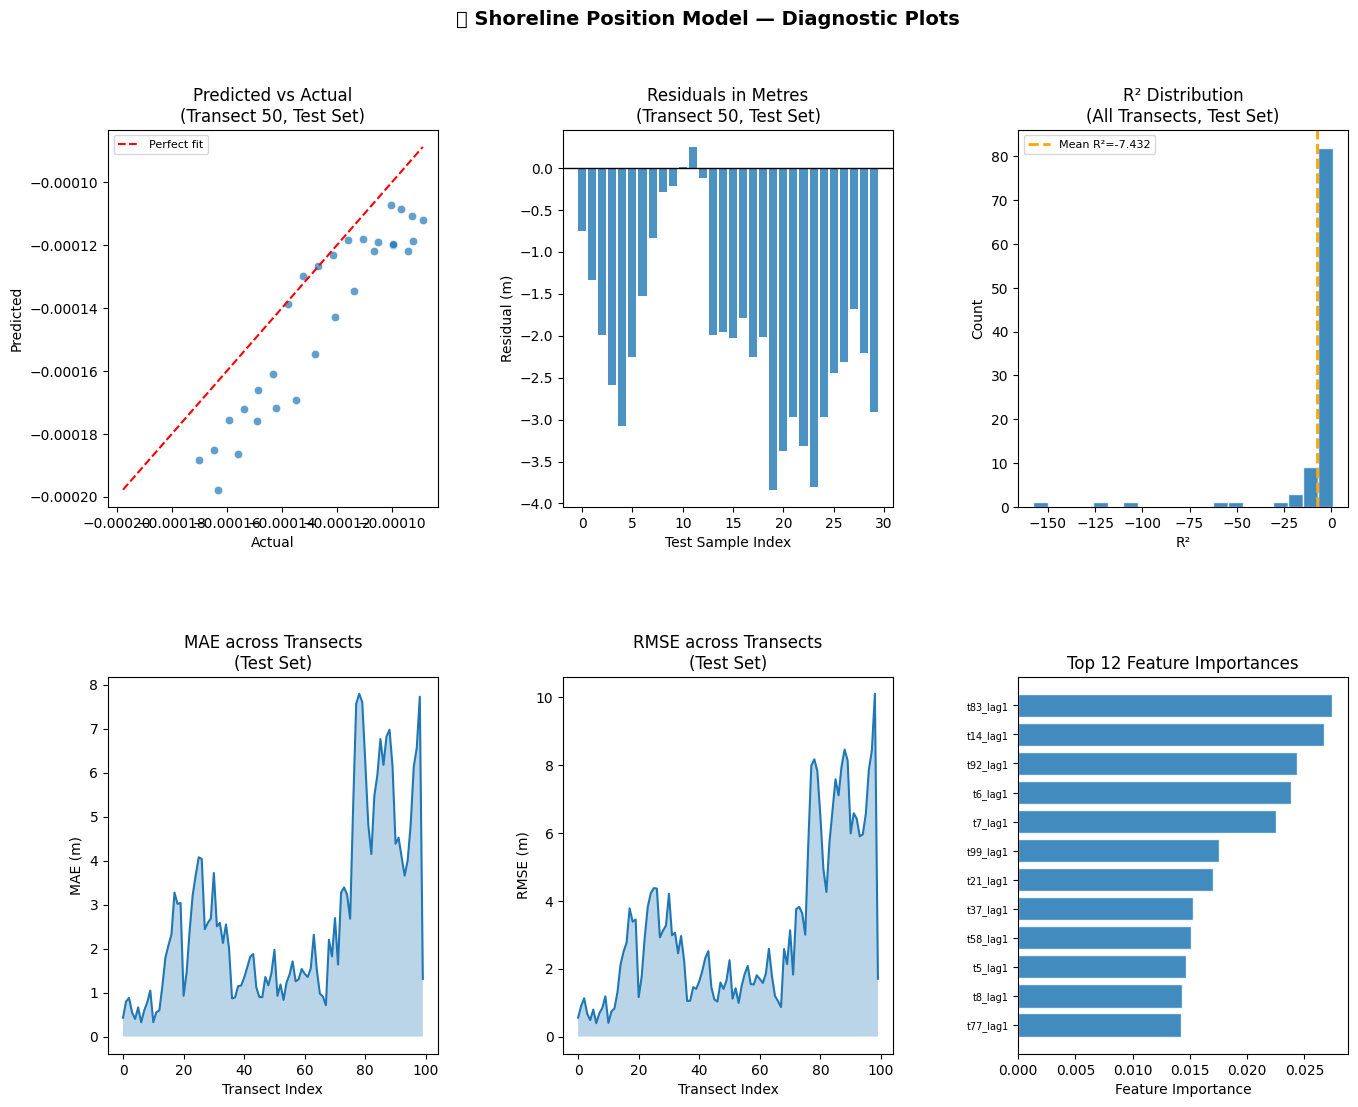

✅ Diagnostic plots saved → data_cache\output_forecasts\diagnostic_plots.png


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# -----------------------
# SAFETY: ensure arrays
# -----------------------
y_test_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred_test)

mid = len(transect_cols) // 2  # representative central transect

# handle NaNs in r2_te (constant series can cause NaN)
r2_te_safe = np.asarray(r2_te, dtype=float)
r2_te_safe = r2_te_safe[~np.isnan(r2_te_safe)]
if len(r2_te_safe) == 0:
    r2_te_safe = np.array([0.0])

# -----------------------
# Feature importance (safe)
# -----------------------
importances = None
try:
    # MultiOutputRegressor -> list of estimators, one per transect
    if hasattr(model, "estimators_") and model.estimators_ is not None:
        fi_list = []
        for est in model.estimators_:
            if hasattr(est, "feature_importances_"):
                fi_list.append(est.feature_importances_)
        if len(fi_list) > 0:
            importances = np.mean(np.vstack(fi_list), axis=0)
except Exception as e:
    print("⚠️ Feature importance skipped:", e)
    importances = None

# -----------------------
# Plot
# -----------------------
fig = plt.figure(figsize=(16, 12))
fig.suptitle("🌊 Shoreline Position Model — Diagnostic Plots", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# (A) Predicted vs Actual — test set (central transect)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test_arr[:, mid], y_pred_arr[:, mid], alpha=0.7, edgecolors="white", lw=0.5)
lims = [
    float(min(y_test_arr[:, mid].min(), y_pred_arr[:, mid].min())),
    float(max(y_test_arr[:, mid].max(), y_pred_arr[:, mid].max()))
]
ax1.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
ax1.set_xlabel("Actual")
ax1.set_ylabel("Predicted")
ax1.set_title(f"Predicted vs Actual\n(Transect {mid}, Test Set)")
ax1.legend(fontsize=8)

# (B) Residuals over test time (meters)
ax2 = fig.add_subplot(gs[0, 1])
residuals_m = (y_pred_arr[:, mid] - y_test_arr[:, mid]) * METERS_PER_DEGREE
ax2.bar(range(len(residuals_m)), residuals_m, alpha=0.8)
ax2.axhline(0, color="black", lw=1)
ax2.set_xlabel("Test Sample Index")
ax2.set_ylabel("Residual (m)")
ax2.set_title(f"Residuals in Metres\n(Transect {mid}, Test Set)")

# (C) R² distribution across transects
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(r2_te_safe, bins=20, edgecolor="white", alpha=0.85)
ax3.axvline(np.mean(r2_te_safe), color="orange", lw=2, linestyle="--",
            label=f"Mean R²={np.mean(r2_te_safe):.3f}")
ax3.set_xlabel("R²")
ax3.set_ylabel("Count")
ax3.set_title("R² Distribution\n(All Transects, Test Set)")
ax3.legend(fontsize=8)

# (D) MAE across transects
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(range(len(mae_te)), mae_te, lw=1.5)
ax4.fill_between(range(len(mae_te)), mae_te, alpha=0.3)
ax4.set_xlabel("Transect Index")
ax4.set_ylabel("MAE (m)")
ax4.set_title("MAE across Transects\n(Test Set)")

# (E) RMSE across transects
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(range(len(rmse_te)), rmse_te, lw=1.5)
ax5.fill_between(range(len(rmse_te)), rmse_te, alpha=0.3)
ax5.set_xlabel("Transect Index")
ax5.set_ylabel("RMSE (m)")
ax5.set_title("RMSE across Transects\n(Test Set)")

# (F) Feature importance
ax6 = fig.add_subplot(gs[1, 2])
if importances is None:
    ax6.text(0.05, 0.6,
             "Feature importance not available\n"
             "(either model not fit, or estimator has no feature_importances_).",
             fontsize=10)
    ax6.set_axis_off()
else:
    top_n = min(12, len(importances))
    top_idx = np.argsort(importances)[-top_n:]
    top_names = [feature_cols[i] for i in top_idx]
    top_vals = importances[top_idx]

    ax6.barh(range(top_n), top_vals, edgecolor="white", alpha=0.85)
    ax6.set_yticks(range(top_n))
    ax6.set_yticklabels(top_names, fontsize=7)
    ax6.set_xlabel("Feature Importance")
    ax6.set_title(f"Top {top_n} Feature Importances")

out_path = OUTPUT_DIR / "diagnostic_plots.png"
plt.savefig(str(out_path), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Diagnostic plots saved →", out_path)

In [38]:
from dateutil.relativedelta import relativedelta

# ==============================
# Forecast Date (past or future)
# ==============================
today = pd.Timestamp.today().normalize()
target_date = pd.Timestamp(TARGET_DATE)

days_ahead = (target_date.date() - today.date()).days

# Allow both past (validation) and future (forecasting) dates
if days_ahead < 0:
    print(f"✅ Backtesting mode: forecasting for {target_date.date()} ({abs(days_ahead)} days in the past)")
else:
    print(f"✅ Forecast mode: target date {target_date.date()} ({days_ahead} days ahead)")

# ── Seasonal analogue: look back 1 year from target date ──
past_date = target_date - relativedelta(years=1)
X_all = merged_df[feature_cols].copy()
idx2 = X_all.index.get_indexer([past_date], method="nearest")[0]
future_env_df = X_all.iloc[[idx2]].copy()
future_env_df.index = [target_date]

# Scale + predict
future_env_sc = scaler.transform(future_env_df.values)
pred_vals = model.predict(future_env_sc)[0]

# Reconstruct shoreline coordinates
def reconstruct_coords(transect_values, origins, normal):
    return origins + np.outer(transect_values, normal)

coords_forecast = reconstruct_coords(pred_vals, transect_origins, normal_vec)

# Change vs last known
last_known = shore_df_aug.iloc[-1][transect_cols].values
delta = (pred_vals - last_known) * METERS_PER_DEGREE

print("\n" + "="*50)
print("📍 FORECAST SUMMARY")
print("="*50)
print(f"  Target date    : {target_date.date()}")
print(f"  Mean change    : {delta.mean():.2f} m  ({'erosion 🔴' if delta.mean()>0 else 'accretion 🟢'})")
print(f"  Max retreat    : {delta.min():.2f} m")
print(f"  Max advance    : {delta.max():.2f} m")

✅ Backtesting mode: forecasting for 2025-01-13 (476 days in the past)

📍 FORECAST SUMMARY
  Target date    : 2025-01-13
  Mean change    : -5.47 m  (accretion 🟢)
  Max retreat    : -21.14 m
  Max advance    : 6.65 m


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# PREDICT ENVIRONMENTAL VARIABLES FOR FORECAST DATE
# Using a ±15-day seasonal window over the last 3 years to produce a
# more robust estimate than a single-day analogue.
# ─────────────────────────────────────────────────────────────────────────────

env_target_cols = [c for c in ["wind_speed","fg10","msl","tp","vhm0","vtpk","vmdr","wave_energy"]
                   if c in env_df.columns]

window_days = 15
years_back  = 3

env_rows = []
for yr in range(1, years_back + 1):
    centre = target_date - relativedelta(years=yr)
    mask   = (env_df.index >= centre - pd.Timedelta(days=window_days)) &              (env_df.index <= centre + pd.Timedelta(days=window_days))
    if mask.sum() > 0:
        env_rows.append(env_df.loc[mask, env_target_cols])

if env_rows:
    env_window = pd.concat(env_rows)
    env_pred = env_window.mean()
    env_std  = env_window.std()
else:
    # fall back to single nearest row
    env_pred = env_df[env_target_cols].iloc[
        env_df.index.get_indexer([past_date], method="nearest")[0]]
    env_std  = pd.Series(0, index=env_target_cols)

# Pretty-print table
UNITS = {
    "wind_speed": "m/s", "fg10": "m/s", "msl": "Pa",
    "tp": "m/day", "vhm0": "m", "vtpk": "s", "vmdr": "°", "wave_energy": "m²"
}
NAMES = {
    "wind_speed": "Wind Speed",  "fg10": "Wind Gust",
    "msl": "Sea Level Pressure", "tp": "Total Precipitation",
    "vhm0": "Sig. Wave Height",  "vtpk": "Wave Peak Period",
    "vmdr": "Wave Direction",    "wave_energy": "Wave Energy Proxy"
}

print("\n" + "="*65)
print(f"🌊 PREDICTED ENVIRONMENTAL CONDITIONS — {target_date.date()}")
print("="*65)
print(f"  (Seasonal window: ±{window_days} days over past {years_back} years)")
print("-"*65)
print(f"  {'Variable':<25} {'Mean':>10} {'Std':>10} {'Unit':>8}")
print("-"*65)
for col in env_target_cols:
    name = NAMES.get(col, col)
    mean_val = env_pred[col]
    std_val  = env_std[col]
    unit     = UNITS.get(col, "")
    print(f"  {name:<25} {mean_val:>10.4f} {std_val:>10.4f} {unit:>8}")
print("="*65)

# Also as a DataFrame for notebook display
env_table = pd.DataFrame({
    "Variable": [NAMES.get(c, c) for c in env_target_cols],
    "Predicted Mean":  [round(env_pred[c], 4) for c in env_target_cols],
    "Std Dev":         [round(env_std[c], 4)  for c in env_target_cols],
    "Unit":            [UNITS.get(c, "")      for c in env_target_cols],
})
env_table



🌊 PREDICTED ENVIRONMENTAL CONDITIONS — 2025-01-13
  (Seasonal window: ±15 days over past 3 years)
-----------------------------------------------------------------
  Variable                        Mean        Std     Unit
-----------------------------------------------------------------
  Wind Speed                    1.1546     0.9030      m/s
  Wind Gust                     4.0728     0.7335      m/s
  Sea Level Pressure        101150.2908   119.9968       Pa
  Total Precipitation           0.0001     0.0002    m/day
  Sig. Wave Height              0.6696     0.1100        m
  Wave Peak Period             13.5608     2.1664        s
  Wave Direction              214.4887    23.0290        °
  Wave Energy Proxy             0.4603     0.1555       m²


,Variable,Predicted Mean,Std Dev,Unit
0,Wind Speed,1.1546,0.9030,m/s
1,Wind Gust,4.0728,0.7335,m/s
2,Sea Level Pressure,101150.2908,119.9968,Pa
3,Total Precipitation,0.0001,0.0002,m/day
4,Sig. Wave Height,0.6696,0.1100,m
5,Wave Peak Period,13.5608,2.1664,s
6,Wave Direction,214.4887,23.0290,°
7,Wave Energy Proxy,0.4603,0.1555,m²


In [40]:
def export_forecast_kml(prediction_coords, date_str, output_path, reference_coords=None):
    pred_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in prediction_coords])
    ref_placemark = ""
    if reference_coords is not None:
        ref_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in reference_coords])
        ref_placemark = f"""
    <Placemark>
      <name>Current Shoreline (Reference)</name>
      <styleUrl>#whiteLine</styleUrl>
      <LineString><tessellate>1</tessellate>
        <coordinates>{ref_str}</coordinates>
      </LineString>
    </Placemark>"""

    kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>Forecast {date_str}</name>
    <Style id="redLine"><LineStyle><color>ff0000ff</color><width>3</width></LineStyle></Style>
    <Style id="whiteLine"><LineStyle><color>ffffffff</color><width>2</width></LineStyle></Style>
    <Placemark>
      <name>Forecast {date_str}</name>
      <styleUrl>#redLine</styleUrl>
      <LineString><tessellate>1</tessellate>
        <coordinates>{pred_str}</coordinates>
      </LineString>
    </Placemark>
    {ref_placemark}
  </Document>
</kml>"""
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(kml_content)
    print("✅ KML saved:", output_path)

# For validation, do not create the normal forecast KML.
# We will create a separate validation KML later with:
# Actual 2025 shoreline + Forecasted 2025 shoreline.

print("\n✅ Forecast coordinates prepared for validation.")
print("   Validation KML will be created after loading the actual 2025 shoreline.")



✅ Forecast coordinates prepared for validation.
   Validation KML will be created after loading the actual 2025 shoreline.


# 🔍 Validation Analysis — Predicted vs Actual Shoreline (2025-01-13)

In [41]:
import glob
import xml.etree.ElementTree as ET

# Find and load the actual shoreline KML for 2025-01-13
kml_pattern = str(KML_FOLDER / "SWnew*01132025*.kml")
actual_kml_files = glob.glob(kml_pattern)

if not actual_kml_files:
    # Try alternate pattern
    kml_pattern2 = str(KML_FOLDER / "*01132025*.kml")
    actual_kml_files = glob.glob(kml_pattern2)

if actual_kml_files:
    actual_kml_file = actual_kml_files[0]
    print(f"✅ Found actual shoreline: {actual_kml_file}")
    
    # Parse the KML
    tree = ET.parse(actual_kml_file)
    root = tree.getroot()
    
    actual_coords = []
    for elem in root.iter():
        if elem.tag.endswith("coordinates") and elem.text:
            for p in elem.text.strip().split():
                lon, lat, *_ = p.split(",")
                actual_coords.append([float(lon), float(lat)])
    
    if actual_coords:
        actual_coords = np.array(actual_coords)
        print(f"✅ Actual shoreline points: {len(actual_coords)}")
        print(f"✅ Actual bounds: LAT [{actual_coords[:, 1].min():.6f}, {actual_coords[:, 1].max():.6f}] LON [{actual_coords[:, 0].min():.6f}, {actual_coords[:, 0].max():.6f}]")
    else:
        actual_coords = None
        print("⚠️ No coordinate data found in KML")
else:
    print("❌ Actual shoreline KML not found. Check data_cache/shorelines_kml/ for SWnew*01132025*.kml")
    actual_coords = None

✅ Found actual shoreline: data_cache\shorelines_kml\SWnew 01132025.kml
✅ Actual shoreline points: 241
✅ Actual bounds: LAT [6.611664, 6.638301] LON [79.936219, 79.947087]


In [42]:
#added==========================
# ============================================================
# EXPORT VALIDATION KML: Actual 2025 vs Forecasted 2025
# ============================================================

def export_validation_actual_vs_forecast_kml(
    actual_coords,
    forecast_coords,
    date_str,
    output_path,
    reference_coords=None
):
    """
    Creates one KML file containing:
    1. Actual shoreline for the validation date
    2. Forecasted shoreline for the same validation date
    3. Optional reference shoreline
    """

    actual_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in actual_coords])
    forecast_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in forecast_coords])

    reference_placemark = ""
    if reference_coords is not None:
        reference_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in reference_coords])
        reference_placemark = f"""
    <Placemark>
      <name>Reference Shoreline</name>
      <styleUrl>#referenceLine</styleUrl>
      <LineString>
        <tessellate>1</tessellate>
        <coordinates>{reference_str}</coordinates>
      </LineString>
    </Placemark>
        """

    kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>Validation Actual vs Forecast {date_str}</name>

    <!-- Actual 2025 shoreline = Blue -->
    <Style id="actualLine">
      <LineStyle>
        <color>ffff0000</color>
        <width>4</width>
      </LineStyle>
    </Style>

    <!-- Forecasted 2025 shoreline = Red -->
    <Style id="forecastLine">
      <LineStyle>
        <color>ff0000ff</color>
        <width>4</width>
      </LineStyle>
    </Style>

    <!-- Reference shoreline = White -->
    <Style id="referenceLine">
      <LineStyle>
        <color>ffffffff</color>
        <width>2</width>
      </LineStyle>
    </Style>

    <Placemark>
      <name>Actual Shoreline {date_str}</name>
      <styleUrl>#actualLine</styleUrl>
      <LineString>
        <tessellate>1</tessellate>
        <coordinates>{actual_str}</coordinates>
      </LineString>
    </Placemark>

    <Placemark>
      <name>Forecasted Shoreline {date_str}</name>
      <styleUrl>#forecastLine</styleUrl>
      <LineString>
        <tessellate>1</tessellate>
        <coordinates>{forecast_str}</coordinates>
      </LineString>
    </Placemark>

    {reference_placemark}

  </Document>
</kml>
"""

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(kml_content)

    print("✅ Validation KML saved:", output_path)


if actual_coords is not None:
    validation_kml_path = OUTPUT_DIR / f"validation_actual_vs_forecast_{target_date.date()}.kml"

    export_validation_actual_vs_forecast_kml(
    actual_coords=actual_coords,
    forecast_coords=coords_forecast,
    date_str=str(target_date.date()),
    output_path=validation_kml_path,
    reference_coords=None
    )

    print("✅ Validation KML includes:")
    print("   Blue  = Actual shoreline", target_date.date())
    print("   Red   = Forecasted shoreline", target_date.date())
    print("   White = Reference shoreline")
else:
    print("❌ Validation KML was not created because actual_coords is missing.")

✅ Validation KML saved: data_cache\output_forecasts\validation_actual_vs_forecast_2025-01-13.kml
✅ Validation KML includes:
   Blue  = Actual shoreline 2025-01-13
   Red   = Forecasted shoreline 2025-01-13
   White = Reference shoreline


In [43]:
if actual_coords is not None:
    print("\n" + "="*70)
    print("📊 VALIDATION METRICS — Predicted vs Actual Shoreline")
    print("="*70)
    
    # For comparison, we need to align predicted and actual shorelines
    # Option 1: Use transect method (project onto common baseline)
    
    # Get the mean positions for alignment
    actual_mean = actual_coords.mean(axis=0)
    pred_mean = coords_forecast.mean(axis=0)
    
    print(f"\nPredicted shoreline centroid: {pred_mean}")
    print(f"Actual shoreline centroid:   {actual_mean}")
    print(f"Centroid offset:              {np.linalg.norm(pred_mean - actual_mean) * METERS_PER_DEGREE:.2f} m")
    
    # Calculate per-point distances in meters
    # For each point in predicted, find nearest point in actual and vice versa
    from scipy.spatial.distance import cdist
    
    # Distance matrix (lat/lon degrees)
    distances_deg = cdist(coords_forecast, actual_coords)  # shape: (n_pred, n_actual)
    
    # For each predicted point, find closest actual point
    min_dist_idx = distances_deg.argmin(axis=1)
    min_distances_to_actual = distances_deg.min(axis=1)  # in degrees
    min_distances_m = min_distances_to_actual * METERS_PER_DEGREE
    
    # Compute metrics
    mae_m = np.mean(min_distances_m)
    rmse_m = np.sqrt(np.mean(min_distances_m**2))
    max_error_m = np.max(min_distances_m)
    min_error_m = np.min(min_distances_m)
    
    print(f"\n{'-'*70}")
    print(f"ACCURACY METRICS (predicted vs nearest actual point):")
    print(f"{'-'*70}")
    print(f"  MAE  (Mean Absolute Error)  : {mae_m:.2f} m")
    print(f"  RMSE (Root Mean Squared Error): {rmse_m:.2f} m")
    print(f"  Min error (best match)       : {min_error_m:.2f} m")
    print(f"  Max error (worst match)      : {max_error_m:.2f} m")
    print(f"  Std Dev of errors            : {np.std(min_distances_m):.2f} m")
    print("="*70)
    
    # Classification: how many predicted points are within threshold?
    thresholds_m = [5, 10, 15, 20]
    print(f"\n📍 PREDICTION ACCURACY AT THRESHOLDS:")
    for thr in thresholds_m:
        within = (min_distances_m <= thr).sum()
        pct = 100 * within / len(min_distances_m)
        print(f"  Within {thr:2d} m:  {within:3d} points ({pct:5.1f}%)")
else:
    print("⚠️ Cannot calculate validation metrics without actual shoreline data")


📊 VALIDATION METRICS — Predicted vs Actual Shoreline

Predicted shoreline centroid: [79.9412947   6.62485786]
Actual shoreline centroid:   [79.94114733  6.62534277]
Centroid offset:              56.26 m

----------------------------------------------------------------------
ACCURACY METRICS (predicted vs nearest actual point):
----------------------------------------------------------------------
  MAE  (Mean Absolute Error)  : 8.55 m
  RMSE (Root Mean Squared Error): 9.68 m
  Min error (best match)       : 1.71 m
  Max error (worst match)      : 21.46 m
  Std Dev of errors            : 4.54 m

📍 PREDICTION ACCURACY AT THRESHOLDS:
  Within  5 m:   22 points ( 22.0%)
  Within 10 m:   68 points ( 68.0%)
  Within 15 m:   90 points ( 90.0%)
  Within 20 m:   97 points ( 97.0%)


C:\Users\Tharu\AppData\Local\Temp\ipykernel_9948\1827145425.py:72: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Tharu\AppData\Local\Temp\ipykernel_9948\1827145425.py:73: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  fig.savefig(str(OUTPUT_DIR / f"validation_analysis_2025-01-13.png"), dpi=120, bbox_inches='tight')
c:\Users\Tharu\anaconda3\envs\coastal\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


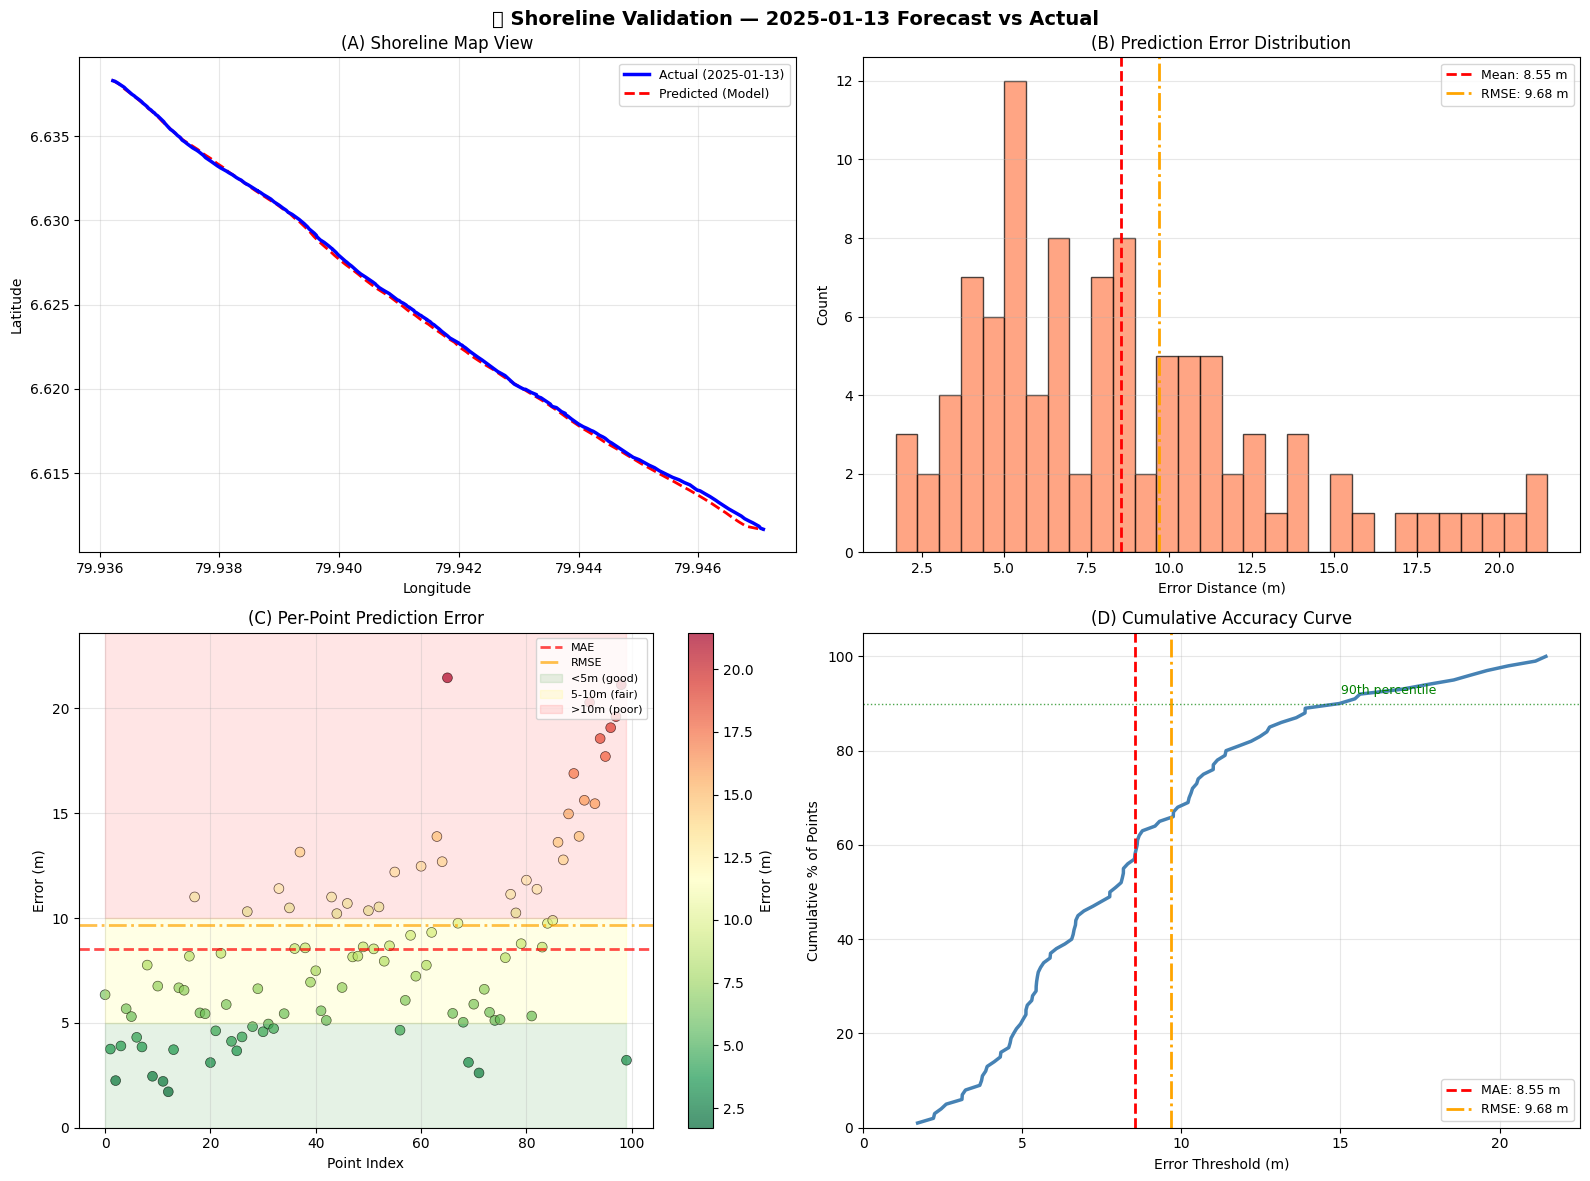

✅ Validation comparison plots saved → validation_analysis_2025-01-13.png


In [44]:
if actual_coords is not None:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"🏖️ Shoreline Validation — 2025-01-13 Forecast vs Actual", fontsize=14, fontweight="bold")
    
    # ─────────────────────────────────────────────────────────────────────────────
    # (A) Map view: Predicted vs Actual
    # ─────────────────────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(actual_coords[:, 0], actual_coords[:, 1], 'b-', lw=2.5, label="Actual (2025-01-13)", zorder=3)
    ax.plot(coords_forecast[:, 0], coords_forecast[:, 1], 'r--', lw=2, label="Predicted (Model)", zorder=2)
    
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("(A) Shoreline Map View")
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    
    # ─────────────────────────────────────────────────────────────────────────────
    # (B) Error distribution (histogram)
    # ─────────────────────────────────────────────────────────────────────────────
    ax = axes[0, 1]
    ax.hist(min_distances_m, bins=30, color='coral', alpha=0.7, edgecolor='black')
    ax.axvline(mae_m, color='red', lw=2, linestyle='--', label=f'Mean: {mae_m:.2f} m')
    ax.axvline(rmse_m, color='orange', lw=2, linestyle='-.', label=f'RMSE: {rmse_m:.2f} m')
    ax.set_xlabel("Error Distance (m)")
    ax.set_ylabel("Count")
    ax.set_title("(B) Prediction Error Distribution")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # ─────────────────────────────────────────────────────────────────────────────
    # (C) Error scatter plot (point-wise)
    # ─────────────────────────────────────────────────────────────────────────────
    ax = axes[1, 0]
    scatter = ax.scatter(range(len(min_distances_m)), min_distances_m, 
                        c=min_distances_m, cmap='RdYlGn_r', s=50, alpha=0.7, edgecolors='black', lw=0.5)
    ax.axhline(mae_m, color='red', lw=2, linestyle='--', alpha=0.7, label='MAE')
    ax.axhline(rmse_m, color='orange', lw=2, linestyle='-.', alpha=0.7, label='RMSE')
    ax.fill_between(range(len(min_distances_m)), 0, 5, alpha=0.1, color='green', label='<5m (good)')
    ax.fill_between(range(len(min_distances_m)), 5, 10, alpha=0.1, color='yellow', label='5-10m (fair)')
    ax.fill_between(range(len(min_distances_m)), 10, 100, alpha=0.1, color='red', label='>10m (poor)')
    ax.set_xlabel("Point Index")
    ax.set_ylabel("Error (m)")
    ax.set_title("(C) Per-Point Prediction Error")
    ax.set_ylim([0, max(min_distances_m) * 1.1])
    ax.legend(fontsize=8, loc='upper right')
    plt.colorbar(scatter, ax=ax, label='Error (m)')
    ax.grid(True, alpha=0.3)
    
    # ─────────────────────────────────────────────────────────────────────────────
    # (D) Cumulative accuracy (performance curve)
    # ─────────────────────────────────────────────────────────────────────────────
    ax = axes[1, 1]
    sorted_errors = np.sort(min_distances_m)
    cumulative_pct = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
    ax.plot(sorted_errors, cumulative_pct, lw=2.5, color='steelblue')
    ax.axvline(mae_m, color='red', lw=2, linestyle='--', label=f'MAE: {mae_m:.2f} m')
    ax.axvline(rmse_m, color='orange', lw=2, linestyle='-.', label=f'RMSE: {rmse_m:.2f} m')
    ax.axhline(90, color='green', lw=1, linestyle=':', alpha=0.7)
    ax.text(sorted_errors[-1]*0.7, 92, '90th percentile', fontsize=9, color='green')
    ax.set_xlabel("Error Threshold (m)")
    ax.set_ylabel("Cumulative % of Points")
    ax.set_title("(D) Cumulative Accuracy Curve")
    ax.set_xlim([0, max(sorted_errors)*1.05])
    ax.set_ylim([0, 105])
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(str(OUTPUT_DIR / f"validation_analysis_2025-01-13.png"), dpi=120, bbox_inches='tight')
    plt.show()
    
    print("✅ Validation comparison plots saved → validation_analysis_2025-01-13.png")
else:
    print("⚠️ Cannot generate plots without actual shoreline data")